In [ ]:
# import essensial libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("book.csv")
df.head()

,Unnamed: 0,book_id,authors,original_publication_year,title,language_code,average_rating,image_url,description
0,0,2767052,Suzanne Collins,2008.0,"The Hunger Games (The Hunger Games, #1)",eng,4.34,https://images.gr-assets.com/books/1447303603m...,First in the ground-breaking HUNGER GAMES tril...
1,1,3,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,https://images.gr-assets.com/books/1474154022m...,Rescued from the outrageous neglect of his aun...
2,2,41865,Stephenie Meyer,2005.0,"Twilight (Twilight, #1)",en-US,3.57,https://images.gr-assets.com/books/1361039443m...,"When 17 year old Isabella Swan moves to Forks,..."
3,3,2657,Harper Lee,1960.0,To Kill a Mockingbird,eng,4.25,https://images.gr-assets.com/books/1361975680m...,Harper Lee's classic novel of a lawyer in the ...
4,4,4671,F. Scott Fitzgerald,1925.0,The Great Gatsby,eng,3.89,https://images.gr-assets.com/books/1490528560m...,The only authorized edition of the twentieth-c...


In [ ]:
print("data size",df.size)

print("shape of data",df.shape)

data size 42894
shape of data (4766, 9)


In [ ]:
df.describe()

,Unnamed: 0,book_id,original_publication_year,average_rating
count,4766.000000,4.766000e+03,4766.000000,4766.000000
mean,2382.500000,5.650215e+06,1988.510071,4.042776
std,1375.970021,7.438062e+06,138.106988,0.233440
min,0.000000,1.000000e+00,-762.000000,2.470000
25%,1191.250000,4.516375e+04,1996.000000,3.900000
50%,2382.500000,5.616825e+05,2006.000000,4.060000
75%,3573.750000,1.051807e+07,2011.000000,4.200000
max,4765.000000,3.153865e+07,2017.000000,4.770000


In [ ]:
df.isnull().sum()

Unnamed: 0                   0
book_id                      0
authors                      0
original_publication_year    0
title                        0
language_code                0
average_rating               0
image_url                    0
description                  0
dtype: int64

In [ ]:
final_cols = [
    'book_id',
    'title',
    'authors',
    'original_publication_year',
    'language_code',
    'average_rating',
    'description'
]

df = df[final_cols]
df.head(10)

,book_id,title,authors,original_publication_year,language_code,average_rating,description
0,2767052,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,2008.0,eng,4.34,First in the ground-breaking HUNGER GAMES tril...
1,3,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",1997.0,eng,4.44,Rescued from the outrageous neglect of his aun...
2,41865,"Twilight (Twilight, #1)",Stephenie Meyer,2005.0,en-US,3.57,"When 17 year old Isabella Swan moves to Forks,..."
3,2657,To Kill a Mockingbird,Harper Lee,1960.0,eng,4.25,Harper Lee's classic novel of a lawyer in the ...
4,4671,The Great Gatsby,F. Scott Fitzgerald,1925.0,eng,3.89,The only authorized edition of the twentieth-c...
5,11870085,The Fault in Our Stars,John Green,2012.0,eng,4.26,I fell in love the way you fall asleep: slowly...
6,5907,The Hobbit,J.R.R. Tolkien,1937.0,en-US,4.25,This is the story of how a Baggins had an adve...
7,5107,The Catcher in the Rye,J.D. Salinger,1951.0,eng,3.79,"REA's MAXnotes for William Faulkner's Absalom,..."
8,1885,Pride and Prejudice,Jane Austen,1813.0,eng,4.24,Elizabeth Bennet and her four sisters need hus...
9,77203,The Kite Runner,Khaled Hosseini,2003.0,eng,4.26,The perennial bestseller-now available as a se...


In [ ]:
df = df.drop(columns=['Unnamed: 0', 'image_url'], errors='ignore')


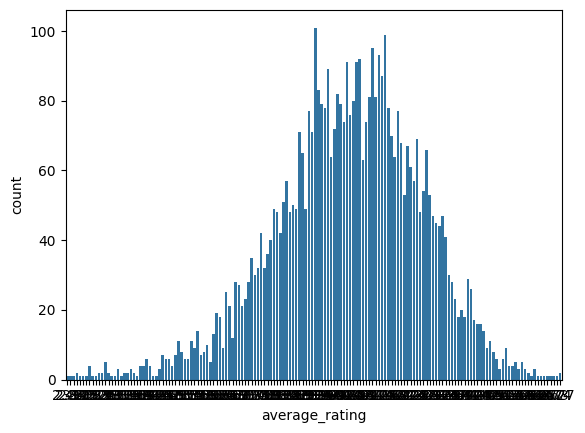

In [ ]:
sns.countplot(x='average_rating', data=df)
plt.show()


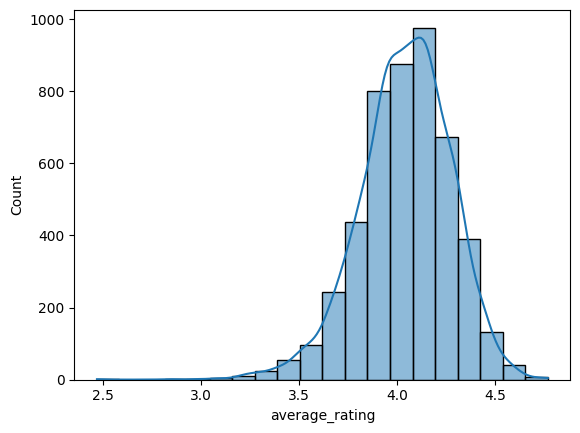

In [ ]:
sns.histplot(df['average_rating'], bins=20, kde=True)
plt.show()


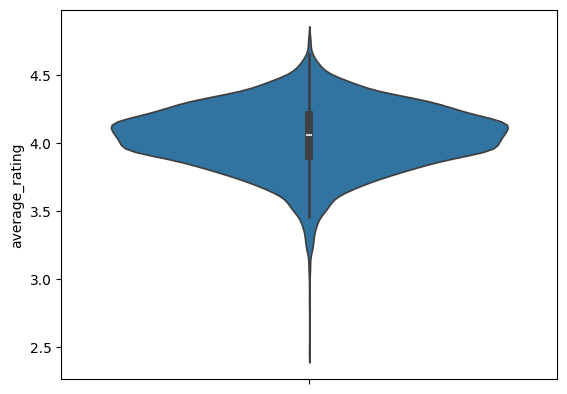

In [ ]:
sns.violinplot(y='average_rating', data=df)
plt.show()


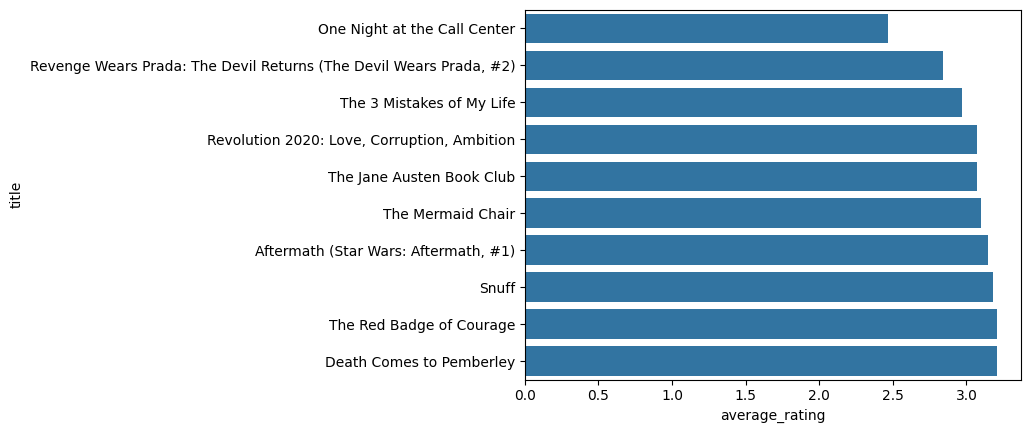

In [ ]:
top_books = df.sort_values('average_rating', ascending=True).head(10)

sns.barplot(
    x='average_rating',
    y='title',
    data=top_books
)
plt.show()


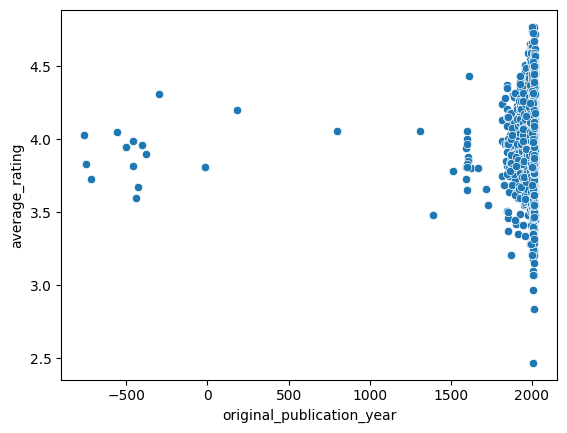

In [ ]:
sns.scatterplot(
    x='original_publication_year',
    y='average_rating',
    data=df
)
plt.show()


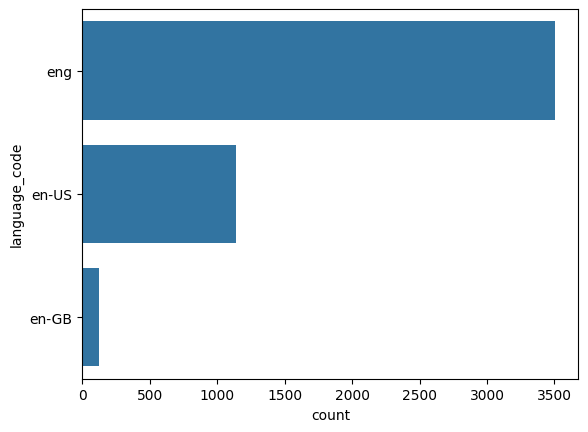

In [ ]:
sns.countplot(
    y='language_code',
    data=df,
    order=df['language_code'].value_counts().index
)
plt.show()


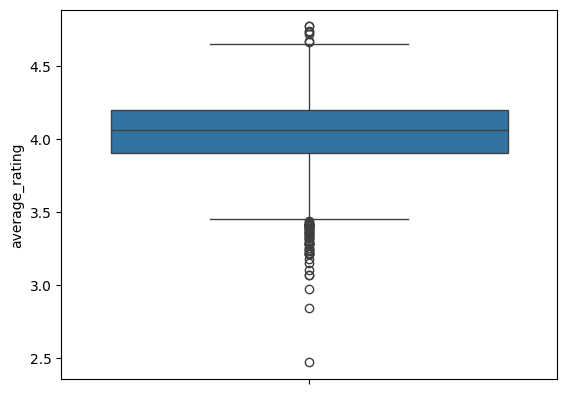

In [ ]:
sns.boxplot(y='average_rating', data=df)
plt.show()


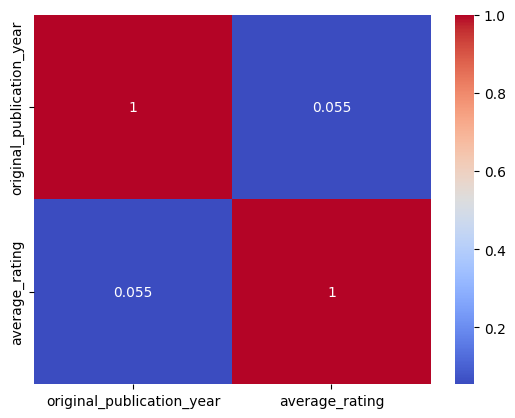

In [ ]:
sns.heatmap(
    df[['original_publication_year', 'average_rating']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()


In [ ]:
df.columns


Index(['book_id', 'title', 'authors', 'original_publication_year',
       'language_code', 'average_rating', 'description'],
      dtype='object')

In [ ]:
df['title'] = df['title'].astype(str)
df['title'] = df['title'].str.replace(r"\s*\(.*?\)", "", regex=True)
df['title'] = df['title'].str.strip()


In [ ]:
df = df[['title', 'authors', 'original_publication_year',
         'average_rating', 'description']].dropna()

df.columns = ['title', 'author', 'year', 'rating', 'description']
df['year'] = df['year'].astype(int)


In [ ]:
df.head()


,title,author,year,rating,description
0,The Hunger Games,Suzanne Collins,2008,4.34,First in the ground-breaking HUNGER GAMES tril...
1,Harry Potter and the Sorcerer's Stone,"J.K. Rowling, Mary GrandPré",1997,4.44,Rescued from the outrageous neglect of his aun...
2,Twilight,Stephenie Meyer,2005,3.57,"When 17 year old Isabella Swan moves to Forks,..."
3,To Kill a Mockingbird,Harper Lee,1960,4.25,Harper Lee's classic novel of a lawyer in the ...
4,The Great Gatsby,F. Scott Fitzgerald,1925,3.89,The only authorized edition of the twentieth-c...


In [ ]:
# Combine title and description
df['content'] = df['title'] + " " + df['description']
df['content'].head()


0    The Hunger Games First in the ground-breaking ...
1    Harry Potter and the Sorcerer's Stone Rescued ...
2    Twilight When 17 year old Isabella Swan moves ...
3    To Kill a Mockingbird Harper Lee's classic nov...
4    The Great Gatsby The only authorized edition o...
Name: content, dtype: object

In [ ]:
print(df.dtypes)

title           object
author          object
year             int64
rating         float64
description     object
content         object
dtype: object


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['content'])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix)




In [ ]:
def recommend_book(book_name):

    # lowercase input
    book_name = book_name.lower()

    # partial match
    book = df[df['title'].str.lower().str.contains(book_name)]

    # agar full phrase match nahi mila
    if book.empty:

        words = book_name.split()

        for w in words:
            book = df[df['title'].str.lower().str.contains(w)]
            if not book.empty:
                break

    if book.empty:
        print("Book not found")
        return

    book_index = book.index[0]

    # similarity scores
    scores = list(enumerate(similarity[book_index]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    similar_books = scores[1:15]

    books = df.iloc[[i[0] for i in similar_books]]

    books = books.sort_values(by='rating', ascending=False)

    top_books = books.head(5)

    print("\nRecommended Books:\n")

    for i in range(len(top_books)):

        title = top_books.iloc[i]['title']
        rating = top_books.iloc[i]['rating']
        desc = top_books.iloc[i]['description']

        print("Title:", title)
        print("Rating:", rating)
        print("Description:", desc)
        print("----------------------------------")


recommend_book("THE")


Recommended Books:

Title: The Hunger Games: Official Illustrated Movie Companion
Rating: 4.51
Description: The New York Times bestseller by Suzanne Collins is now a major motion picture -- and this is your guide to all of the movie's excitement, both in front of the camera and behind it. Go behind the scenes of the making of The Hunger Games with exclusive images and interviews. From the screenwriting process to the casting decisions to the elaborate sets and costumes to the actors' performances and directors' vision, this is the definitive companion to the breathtaking film.
----------------------------------
Title: The Hunger Games Trilogy Boxset
Rating: 4.49
Description: This stunning paperback box set includes all three books in Suzanne Collins's internationally bestselling Hunger Games trilogy together with The Ballad of Songbirds and Snakes. In the ruins of a place once known as North America lies the nation of Panem, a shining Capitol surrounded by twelve outlying districts. T